# For Aryana: z=7.4985 Skewer Analysis

This notebook reproduces all of the exploratory plots for Anson's `Lya_transmission` dataset at `z=7.4985`:

- angle distributions
- density profiles
- density profiles on a log y-axis
- velocity profiles
- transmission spectra

Each plotting cell both saves the figure into `results/for_aryana/` and displays it inline.

In [1]:
from pathlib import Path
import json
import sys

import numpy as np
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from scripts.analyze_for_aryana_z74985 import (
    CELL_SIZE_CMPC_H,
    N_CELLS,
    load_params,
    load_sightlines,
    load_transmission,
    load_wavelengths,
    make_angle_plot,
    make_profile_plot,
    make_transmission_plot,
)


In [2]:
data_dir = PROJECT_ROOT / 'data' / 'for_aryana' / 'late_end_early_start' / 'Lya_transmission'
output_dir = PROJECT_ROOT / 'results' / 'for_aryana'
output_dir.mkdir(parents=True, exist_ok=True)

seed = 7
rng = np.random.default_rng(seed)

params = load_params(data_dir / 'sl_params_z=07.4985')
density, velocity = load_sightlines(data_dir / 'sightlines_z=07.4985')
transmission = load_transmission(data_dir / 'Lya_transmission.z=07.4985')
wav = load_wavelengths(data_dir / 'wav_out')
radius = np.arange(N_CELLS, dtype=np.float32) * CELL_SIZE_CMPC_H

print('data_dir   :', data_dir)
print('output_dir :', output_dir)
print('n_skewers  :', params.shape[0])
print('n_cells    :', density.shape[1])
print('n_wav      :', wav.shape[0])


data_dir   : /home/aryana/Documents/GitHub/Lyman_alpha/data/for_aryana/late_end_early_start/Lya_transmission
output_dir : /home/aryana/Documents/GitHub/Lyman_alpha/results/for_aryana
n_skewers  : 10000
n_cells    : 4000
n_wav      : 2000


## Angle Distributions

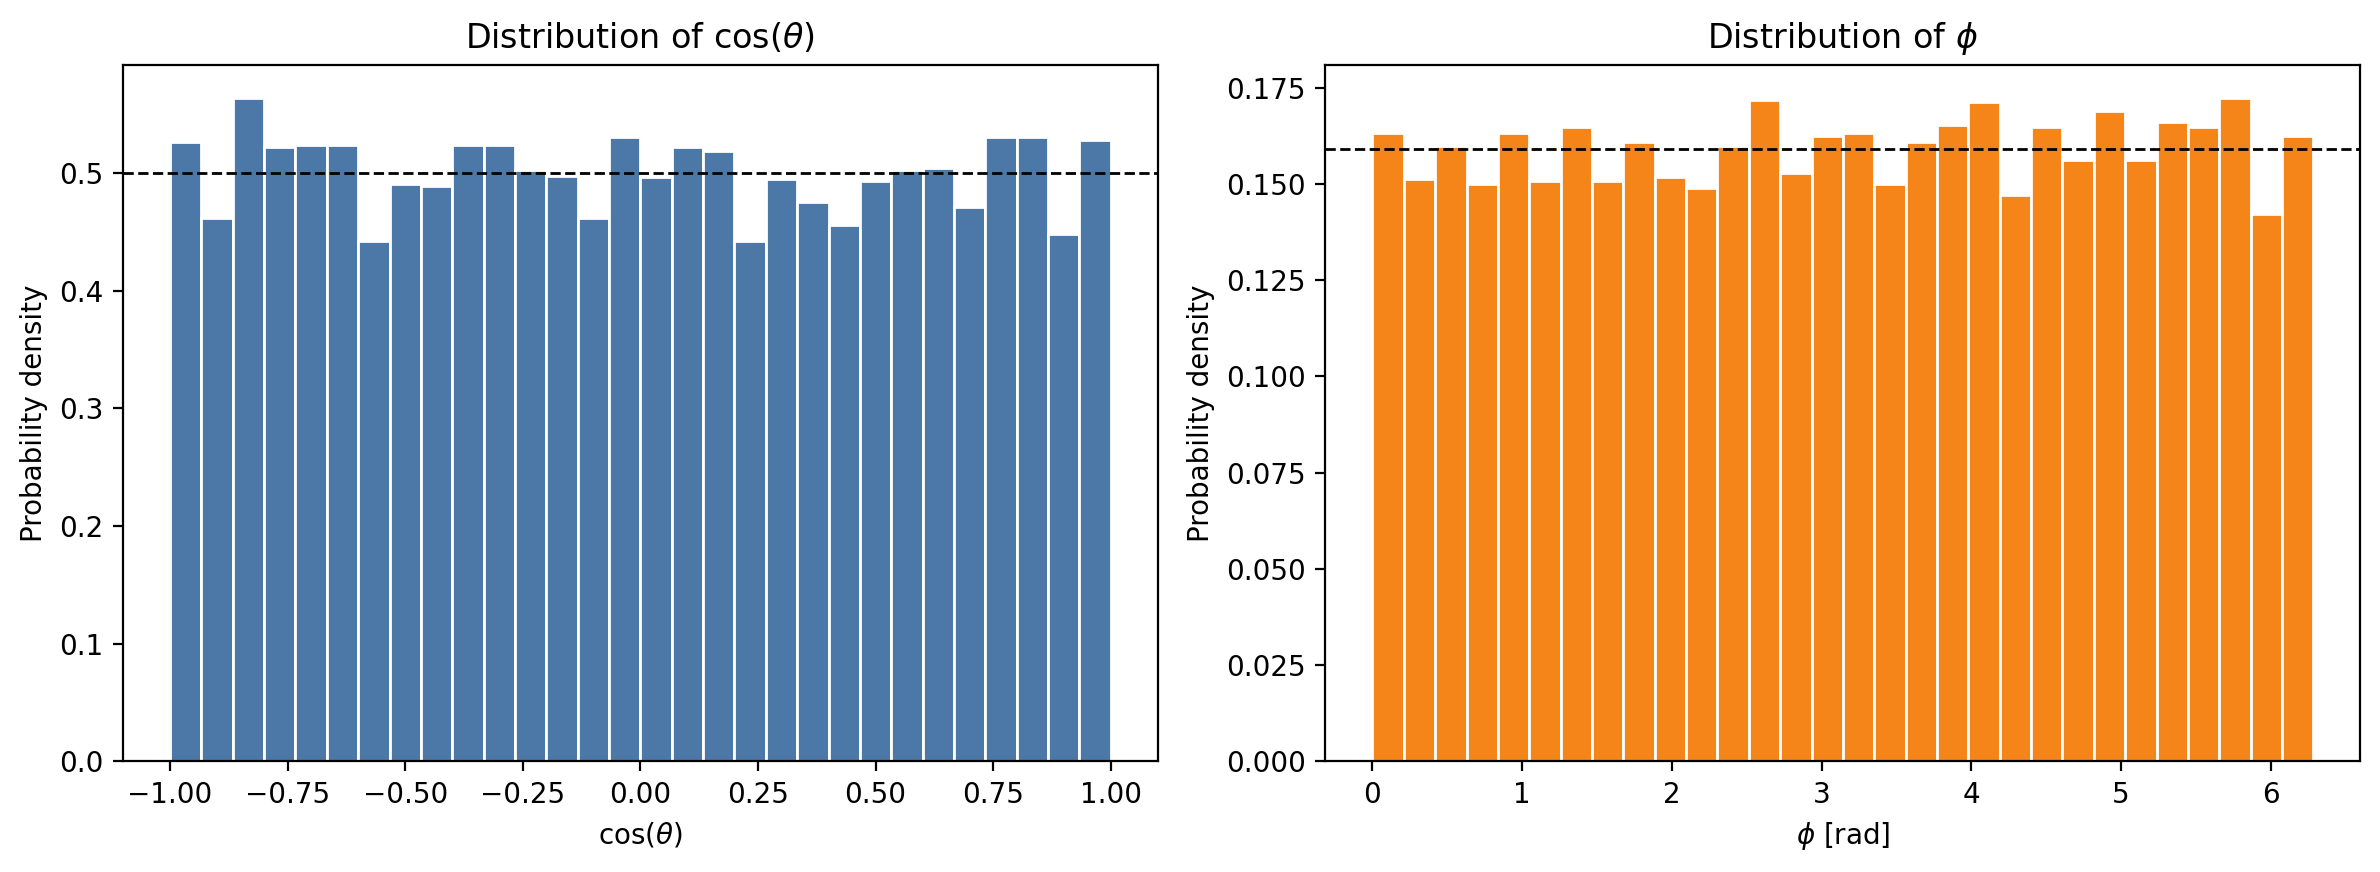

{'cos_theta_mean': -0.0058286008425056934,
 'cos_theta_std': 0.5800429582595825,
 'phi_mean': 3.159560441970825,
 'phi_std': 1.81165611743927,
 'theta_min': 0.0,
 'theta_max': 3.1415927410125732,
 'phi_min': 0.0,
 'phi_max': 6.283180236816406}

In [3]:
angle_stats = make_angle_plot(params, output_dir / 'angle_distributions.png')
display(Image(filename=output_dir / 'angle_distributions.png'))
angle_stats


## Density Profiles

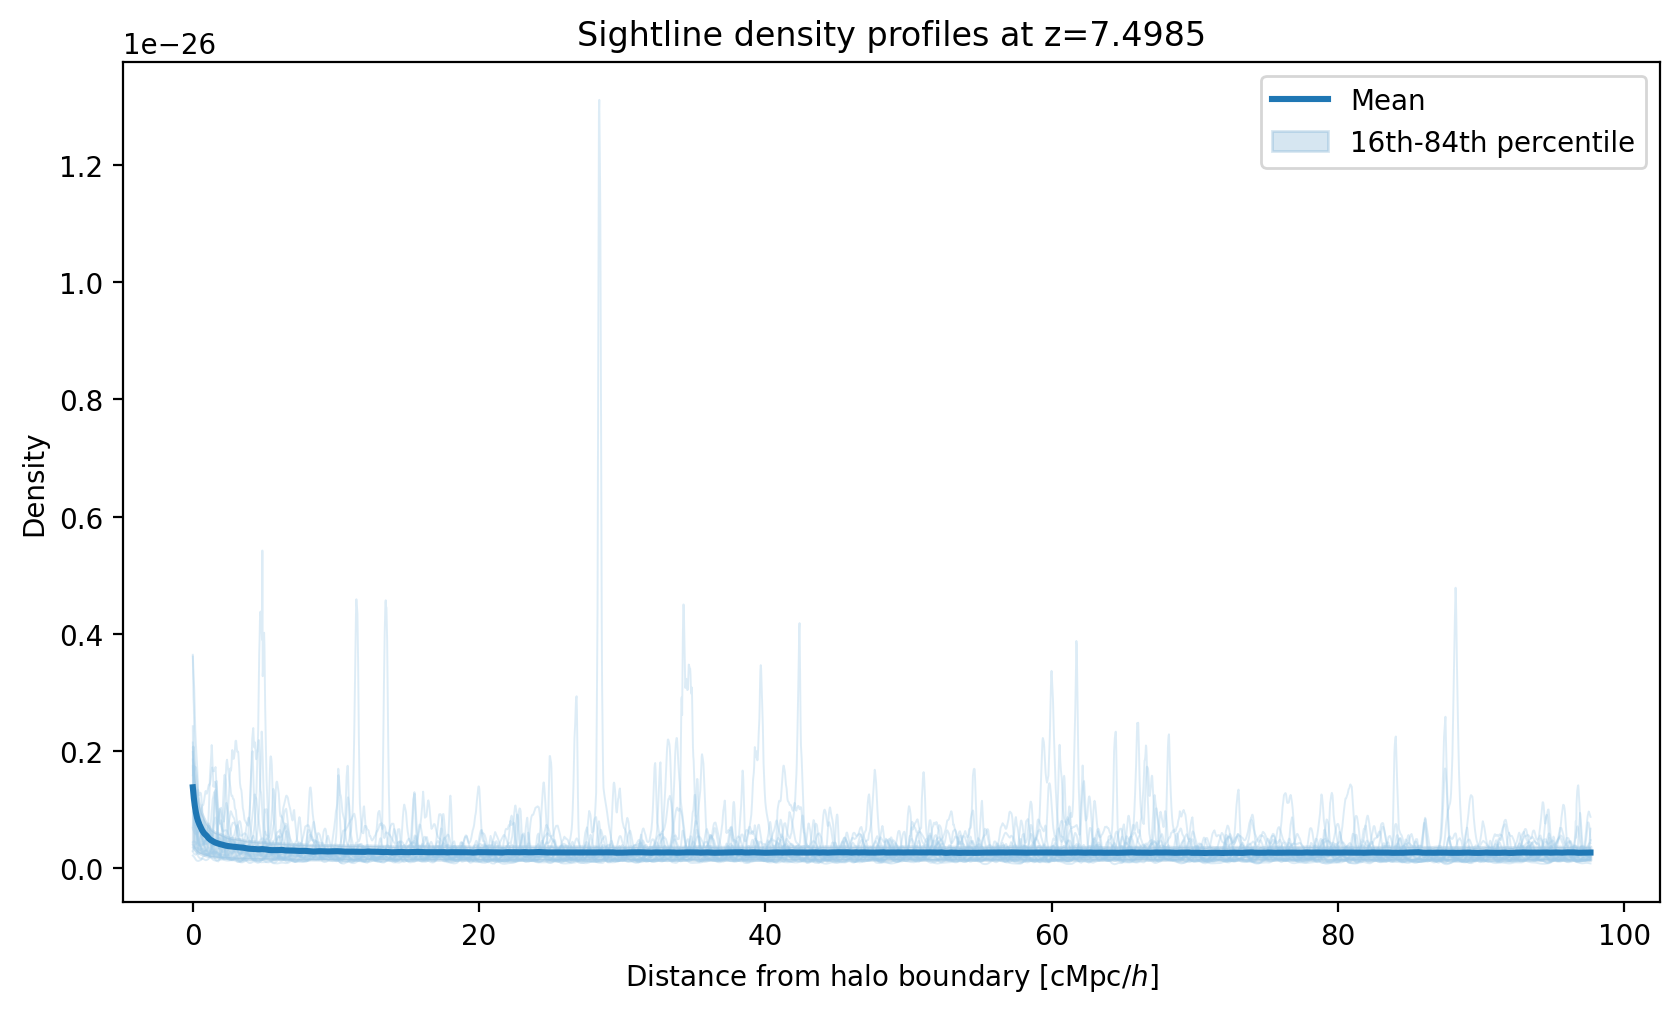

{'mean_start': 1.3724559080797404e-27,
 'mean_mid': 2.564283998538003e-28,
 'mean_end': 2.5747658722603306e-28,
 'global_min': 3.674361069348329e-29,
 'global_max': 1.0632962464241523e-25}

In [4]:
density_stats = make_profile_plot(
    radius,
    density,
    ylabel='Density',
    title='Sightline density profiles at z=7.4985',
    output_path=output_dir / 'density_profiles.png',
    rng=rng,
)
display(Image(filename=output_dir / 'density_profiles.png'))
density_stats


## Density Profiles (Log Scale)

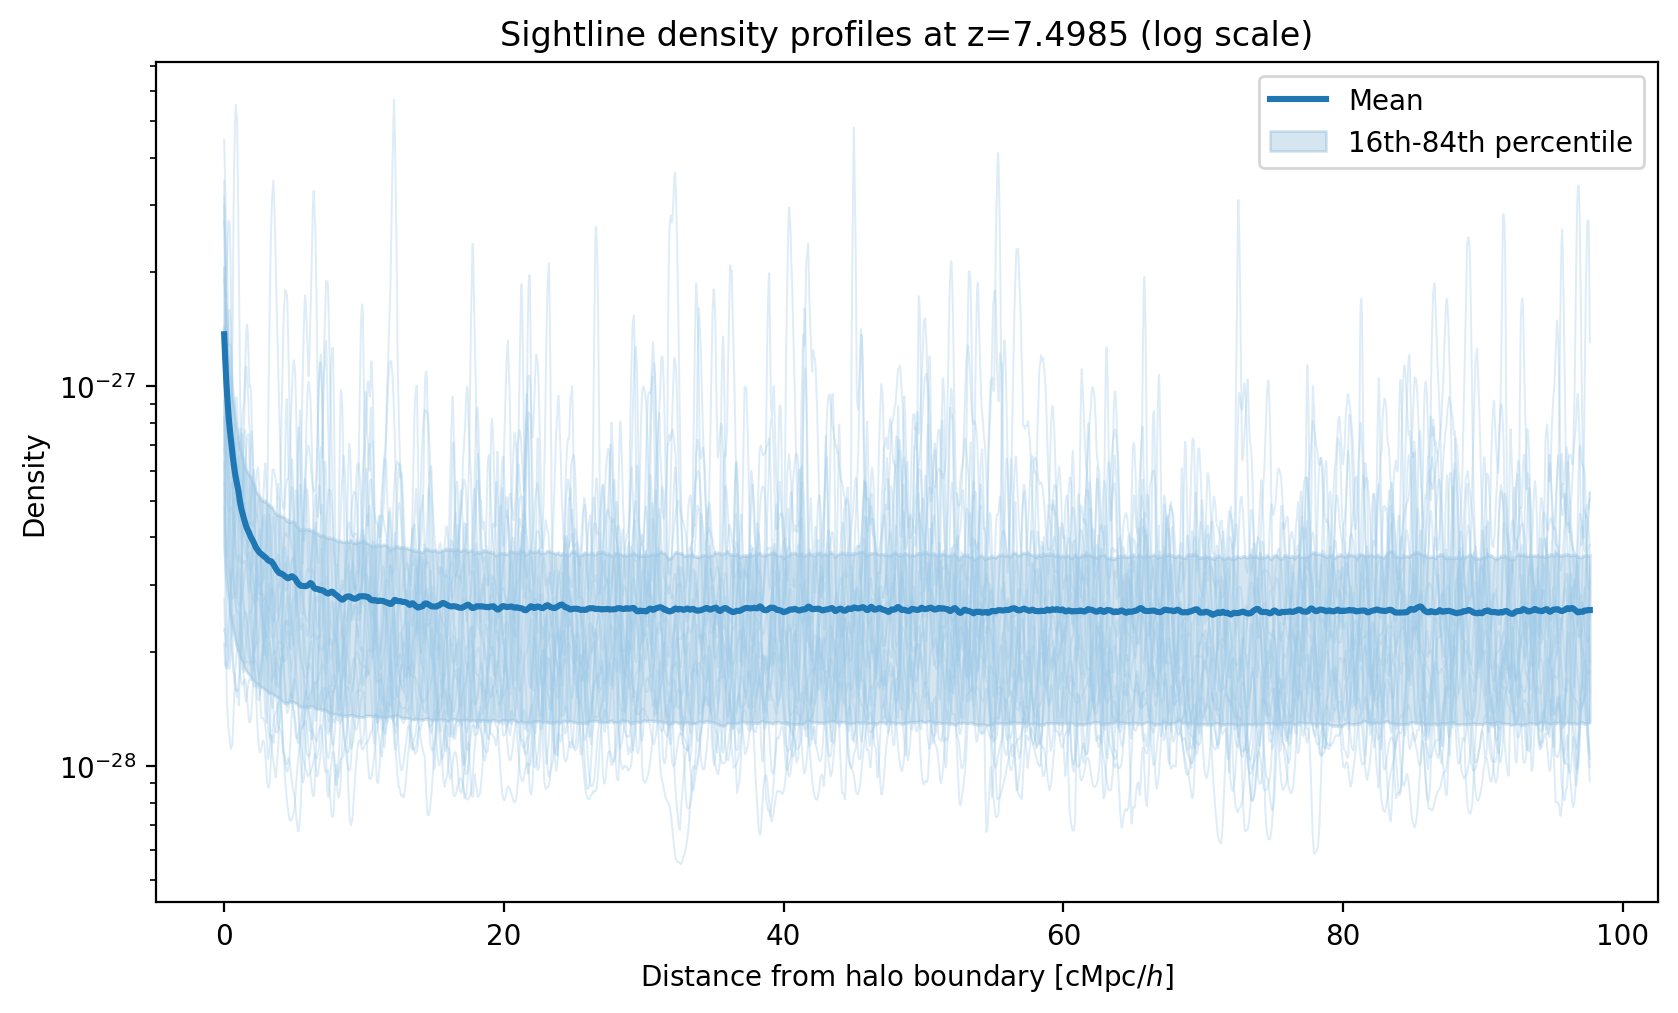

{'mean_start': 1.3724559080797404e-27,
 'mean_mid': 2.564283998538003e-28,
 'mean_end': 2.5747658722603306e-28,
 'global_min': 3.674361069348329e-29,
 'global_max': 1.0632962464241523e-25}

In [5]:
density_log_stats = make_profile_plot(
    radius,
    density,
    ylabel='Density',
    title='Sightline density profiles at z=7.4985 (log scale)',
    output_path=output_dir / 'density_profiles_log.png',
    rng=rng,
    yscale='log',
)
display(Image(filename=output_dir / 'density_profiles_log.png'))
density_log_stats


## Velocity Profiles

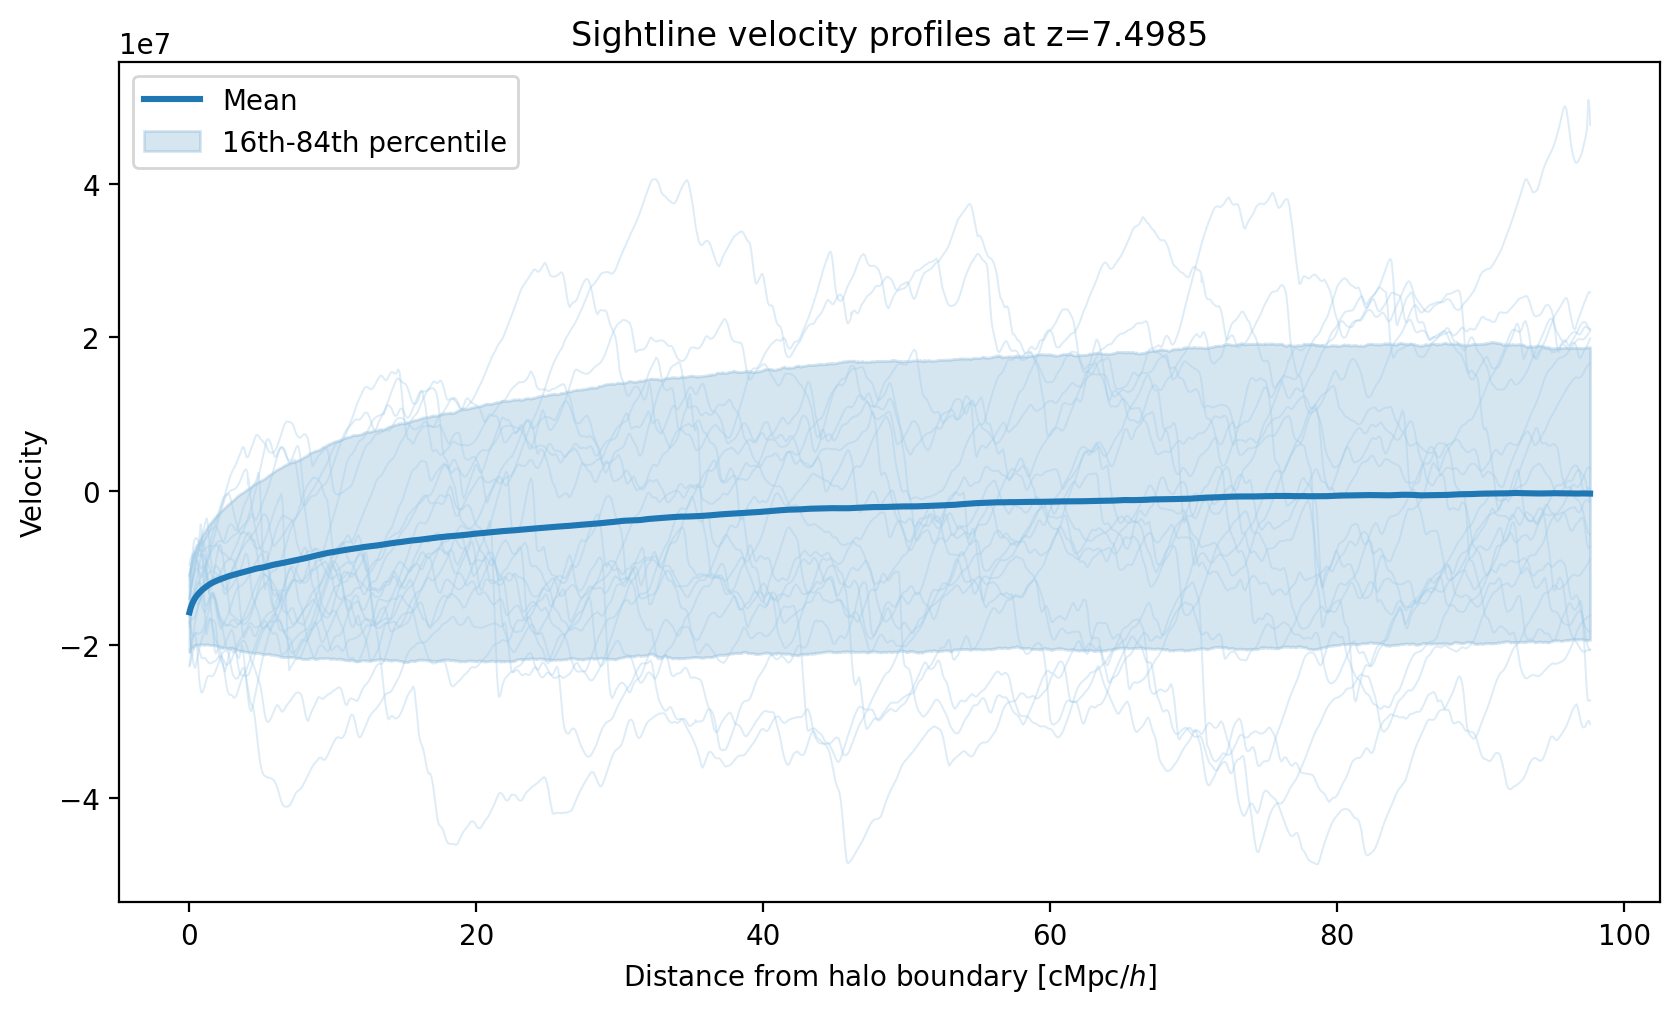

{'mean_start': -15783009.0,
 'mean_mid': -2034550.125,
 'mean_end': -322310.03125,
 'global_min': -90037528.0,
 'global_max': 92033576.0}

In [6]:
velocity_stats = make_profile_plot(
    radius,
    velocity,
    ylabel='Velocity',
    title='Sightline velocity profiles at z=7.4985',
    output_path=output_dir / 'velocity_profiles.png',
    rng=rng,
)
display(Image(filename=output_dir / 'velocity_profiles.png'))
velocity_stats


## Transmission Spectra

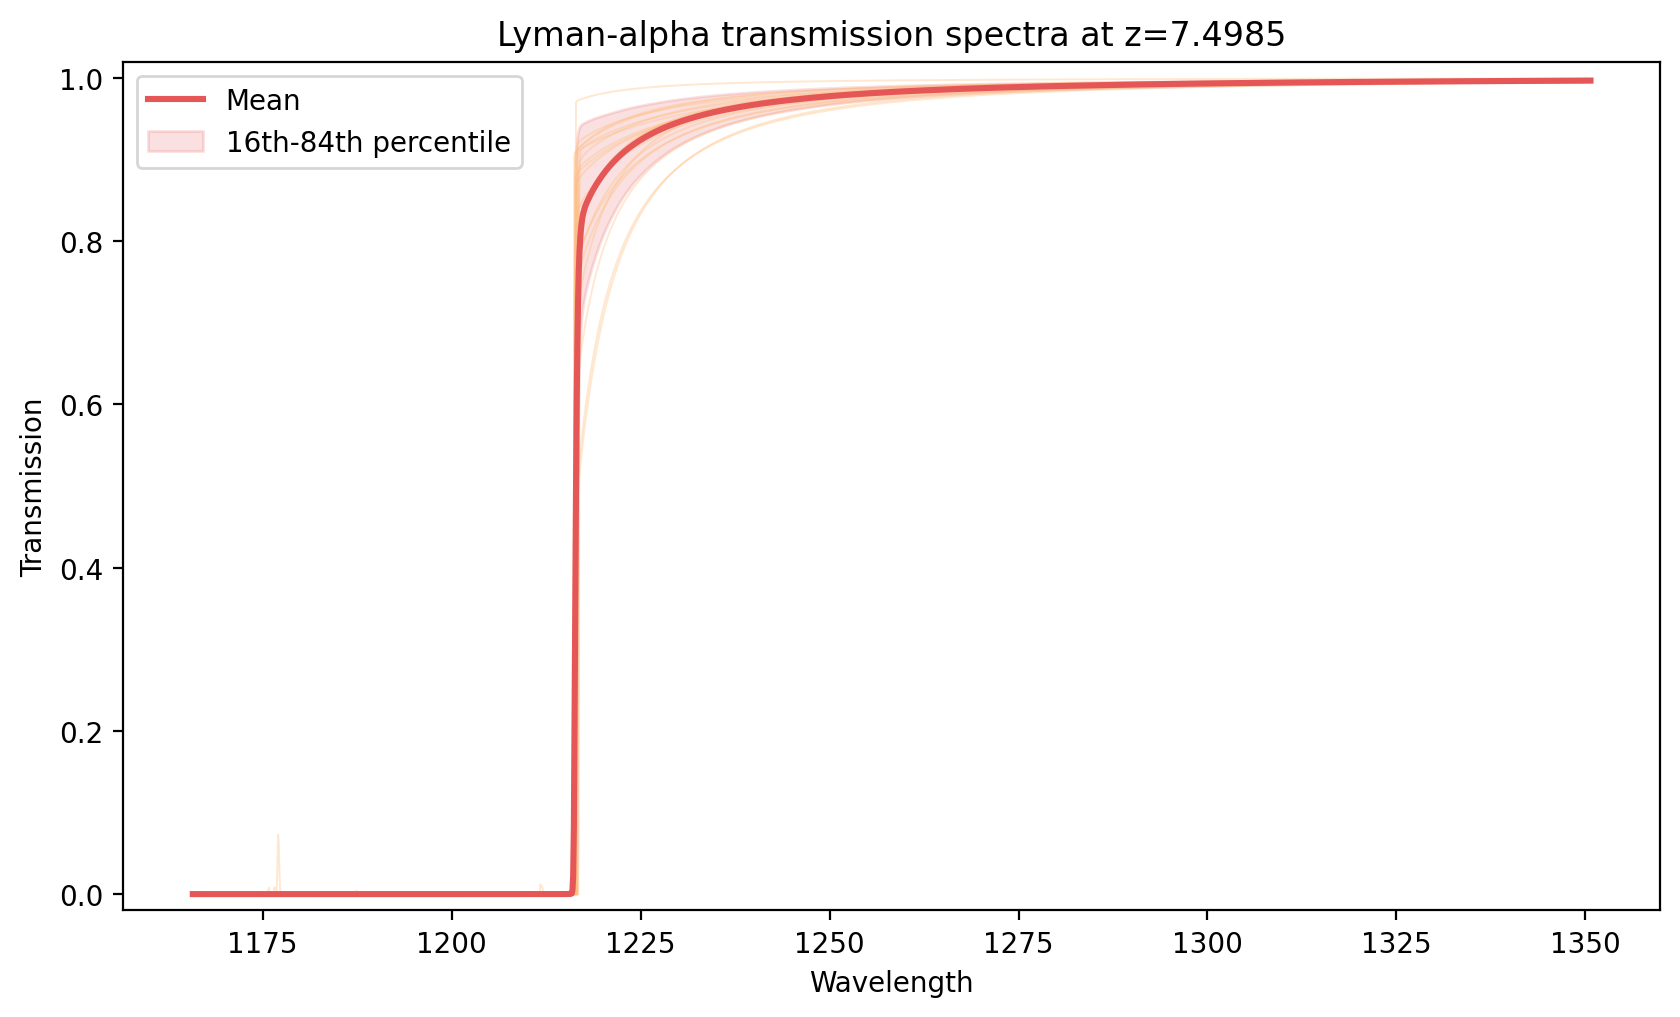

{'mean_transmission_overall': 0.7104248404502869,
 'mean_transmission_min': 2.212225354014663e-06,
 'mean_transmission_max': 0.9968093633651733,
 'wav_min': 1165.762451171875,
 'wav_max': 1350.6700439453125}

In [7]:
transmission_stats = make_transmission_plot(
    wav,
    transmission,
    output_dir / 'transmission_spectra.png',
    rng,
)
display(Image(filename=output_dir / 'transmission_spectra.png'))
transmission_stats


## Summary Stats

In [8]:
summary = {
    'n_skewers': int(params.shape[0]),
    'n_cells_per_skewer': int(density.shape[1]),
    'n_wavelength_bins': int(wav.shape[0]),
    'angle_stats': angle_stats,
    'density_stats': density_stats,
    'density_log_stats': density_log_stats,
    'velocity_stats': velocity_stats,
    'transmission_stats': transmission_stats,
}

summary_path = output_dir / 'summary_stats.json'
summary_path.write_text(json.dumps(summary, indent=2))
print(json.dumps(summary, indent=2))


{
  "n_skewers": 10000,
  "n_cells_per_skewer": 4000,
  "n_wavelength_bins": 2000,
  "angle_stats": {
    "cos_theta_mean": -0.0058286008425056934,
    "cos_theta_std": 0.5800429582595825,
    "phi_mean": 3.159560441970825,
    "phi_std": 1.81165611743927,
    "theta_min": 0.0,
    "theta_max": 3.1415927410125732,
    "phi_min": 0.0,
    "phi_max": 6.283180236816406
  },
  "density_stats": {
    "mean_start": 1.3724559080797404e-27,
    "mean_mid": 2.564283998538003e-28,
    "mean_end": 2.5747658722603306e-28,
    "global_min": 3.674361069348329e-29,
    "global_max": 1.0632962464241523e-25
  },
  "density_log_stats": {
    "mean_start": 1.3724559080797404e-27,
    "mean_mid": 2.564283998538003e-28,
    "mean_end": 2.5747658722603306e-28,
    "global_min": 3.674361069348329e-29,
    "global_max": 1.0632962464241523e-25
  },
  "velocity_stats": {
    "mean_start": -15783009.0,
    "mean_mid": -2034550.125,
    "mean_end": -322310.03125,
    "global_min": -90037528.0,
    "global_max": 9